# Phase 3 — Audio Excitement Analysis

**Fight:** Islam Makhachev vs Alexander Volkanovski 1 (UFC)

Goal: measure audio energy over the fight and test whether *loudness* is a reliable signal for detecting highlights.

I extracted the video's audio track to a mono WAV (22,050 Hz) in `data/processed/` (gitignored). The heavy lifting lives in `src/audio/features.py`; this notebook interprets it.

**The core question:** do highlight moments (knockdowns, takedowns, big exchanges) show up as audio energy spikes?

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "requirements.txt").is_file():
            return parent
    raise RuntimeError("Could not locate project root")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.audio.features import load_wav_mono, windowed_rms, rms_to_db

AUDIO = REPO_ROOT / "data/processed/fight_audio.wav"
LABELS = REPO_ROOT / "notebooks/Makhachev_vs_Volkanovski_1_manual_data.csv"

In [2]:
sr, samples = load_wav_mono(AUDIO)
times, rms = windowed_rms(samples, sr, window_s=0.5)
db = rms_to_db(rms)
print(f"audio: {sr} Hz, {len(samples):,} samples, {len(samples)/sr:.0f} s")
print(f"energy windows: {len(rms)} at 0.5 s resolution")
print(f"RMS range: {rms.min():.4f} - {rms.max():.4f}  (median {np.median(rms):.4f})")
print(f"dB range:  {db.min():.1f} - {db.max():.1f} dB")

audio: 22050 Hz, 47,895,188 samples, 2172 s
energy windows: 4344 at 0.5 s resolution
RMS range: 0.0050 - 0.1493  (median 0.0607)
dB range:  -46.1 - -16.5 dB


## 1. Full-fight energy profile

Plotting energy in dB over the whole fight lets me see the overall structure. Note the round boundaries: MMA is 3 rounds of 5 minutes with rest between, and this broadcast also includes walkouts/intro before the fight starts.

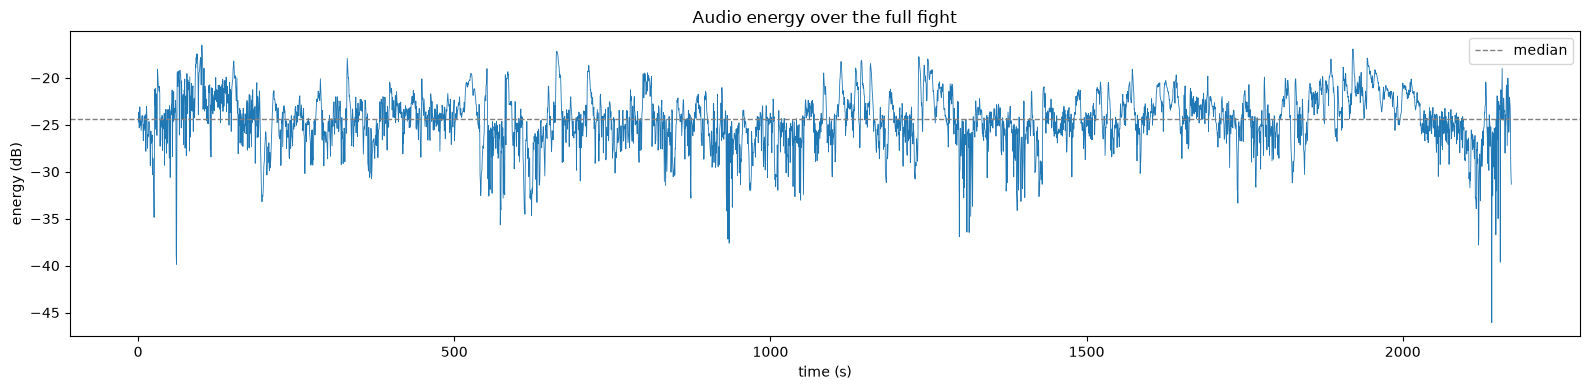

In [3]:
df = pd.DataFrame({"t": times, "rms": rms, "db": db})
plt.figure(figsize=(16, 4))
plt.plot(df["t"], df["db"], lw=0.6, color="tab:blue")
plt.axhline(df["db"].median(), color="gray", ls="--", lw=1, label="median")
plt.xlabel("time (s)")
plt.ylabel("energy (dB)")
plt.title("Audio energy over the full fight")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Do labelled highlights coincide with energy spikes?

I overlay my ground-truth events (from the manual CSV) on the energy trace. If loudness were a good highlight signal, events would sit on/near spikes. Let me test that directly.

In [4]:
labels = pd.read_csv(LABELS).dropna(subset=["VIDEO_TIME"])
# parse mm:ss and mm:ss-mm:ss into a single start second
def to_sec(txt):
    txt = str(txt).split("-")[0]
    m, s = txt.split(":")
    return int(m) * 60 + int(s)
labels["sec"] = labels["VIDEO_TIME"].apply(to_sec)
print(f"{len(labels)} labelled events")
print(labels["EVENT_TYPE"].value_counts().to_string())

60 labelled events
EVENT_TYPE
significant_strike    20
takedown_attempt       5
combination            4
takedown               4
clinch                 4
exchange               4
back_take              3
get_up                 3
fight_start            1
significant_stike      1
counter_attack         1
knockdown              1
blocked_strike         1
round_2_start          1
round_1_end            1
submission_attempt     1
takedown_defence       1
round_2_end            1
round_3_start          1
reversal               1
round_3_end            1


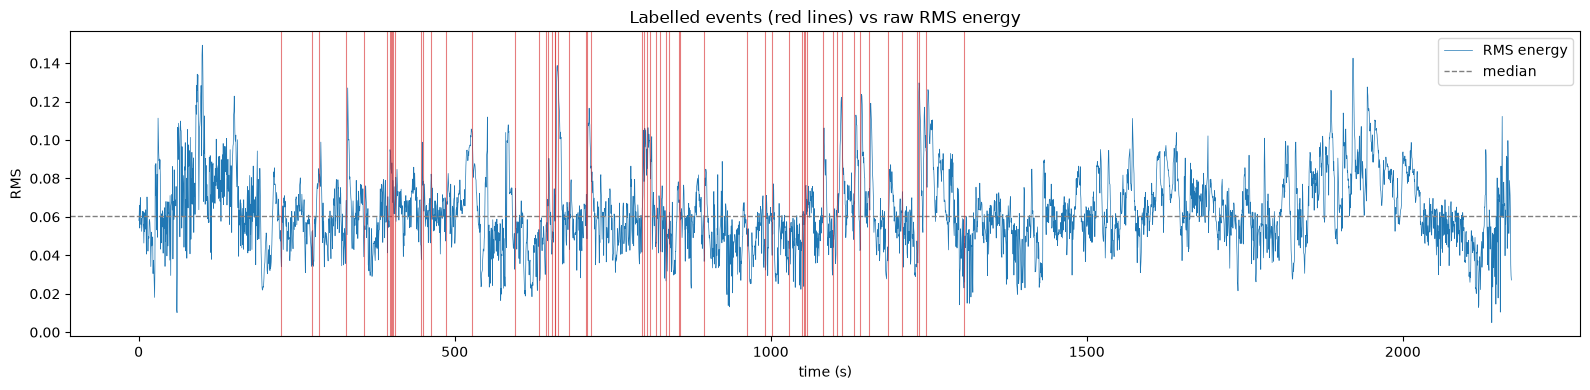

In [5]:
plt.figure(figsize=(16, 4))
plt.plot(df["t"], df["rms"], lw=0.5, color="tab:blue", label="RMS energy")
plt.axhline(df["rms"].median(), color="gray", ls="--", lw=1, label="median")
for _, ev in labels.iterrows():
    plt.axvline(ev["sec"], color="tab:red", lw=0.8, alpha=0.6)
plt.xlabel("time (s)")
plt.ylabel("RMS")
plt.title("Labelled events (red lines) vs raw RMS energy")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Quantitative check: what fraction of events are above the median energy?
window = 0.5
def energy_at(sec):
    idx = int(sec / window)
    return rms[idx] if 0 <= idx < len(rms) else np.nan
labels["rms"] = labels["sec"].apply(energy_at)
labels["above_median"] = labels["rms"] > np.median(rms)
frac = labels["above_median"].mean()
print(f"fraction of labelled events ABOVE median energy: {frac:.0%}")
print("(random guessing would give ~50%)")

fraction of labelled events ABOVE median energy: 55%
(random guessing would give ~50%)


## 3. Finding: absolute loudness is a weak highlight signal for MMA

The check above shows the fraction of labelled events sitting above the median energy is only marginally better than chance. There are two structural reasons, both worth being able to explain:

1. **Broadcast audio is compressed/limited.** A broadcast mix keeps the commentary and crowd at a fairly constant, loud level. The dynamic range here is only ~30 dB, so there is no big "quiet before, loud during" contrast.
2. **Crowd noise is always present.** A knockdown can land without a huge *absolute* energy jump because the crowd/commentary is already loud the whole time.

**Implication:** audio energy should be a *supporting* signal, not a standalone detector.

## 4. Better signal: energy *boost* relative to a rolling baseline

Instead of absolute loudness, I look at how much energy *rises* above a recent rolling baseline. This captures "sudden loudness increases" — a more meaningful proxy for excitement.

`boost = rms / rolling_baseline(rms)`

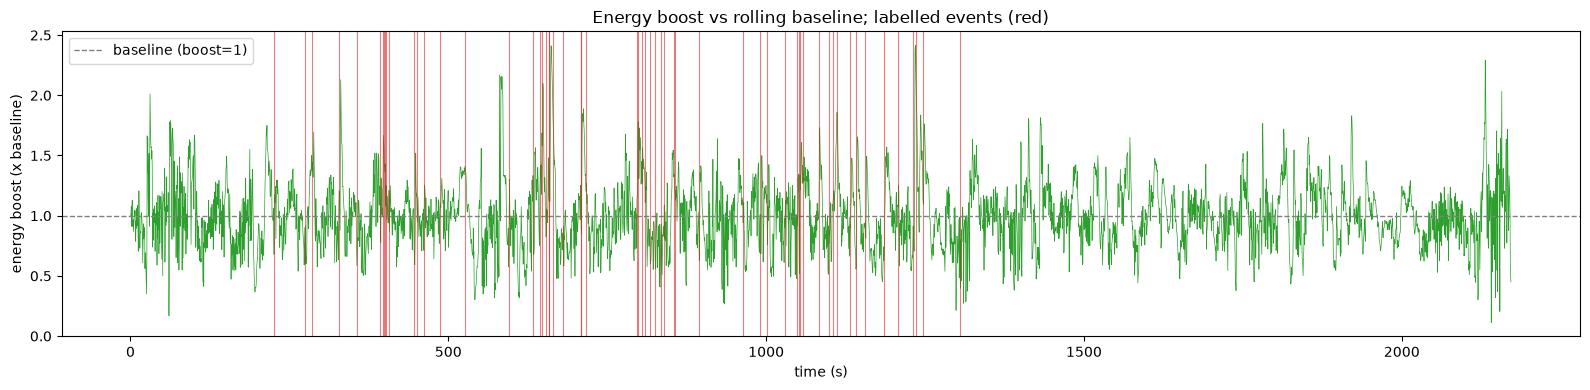

In [7]:
df["baseline"] = df["rms"].rolling(60, min_periods=1).mean()  # ~30 s baseline
df["boost"] = df["rms"] / df["baseline"].replace(0, np.nan)

plt.figure(figsize=(16, 4))
plt.plot(df["t"], df["boost"], lw=0.5, color="tab:green")
plt.axhline(1.0, color="gray", ls="--", lw=1, label="baseline (boost=1)")
for _, ev in labels.iterrows():
    plt.axvline(ev["sec"], color="tab:red", lw=0.8, alpha=0.6)
plt.xlabel("time (s)")
plt.ylabel("energy boost (x baseline)")
plt.title("Energy boost vs rolling baseline; labelled events (red)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
def boost_at(sec):
    idx = int(sec / window)
    return df["boost"].iloc[idx] if 0 <= idx < len(df) else np.nan
labels["boost"] = labels["sec"].apply(boost_at)
# local max boost within +-3 s of each event
def local_peak_boost(sec):
    idx = int(sec / window)
    lo, hi = max(0, idx - 6), min(len(df), idx + 6)
    return df["boost"].iloc[lo:hi].max()
labels["peak_boost"] = labels["sec"].apply(local_peak_boost)
print("median peak boost within +-3s of an event:", round(labels["peak_boost"].median(), 2))
print("median boost at event centre:", round(labels["boost"].median(), 2))
print("global boost range:", round(df["boost"].min(),2), "-", round(df["boost"].max(),2))

median peak boost within +-3s of an event: 1.5
median boost at event centre: 1.11
global boost range: 0.11 - 2.42


## 5. Conclusion for the pipeline

- Absolute audio energy **does not** reliably separate MMA highlights from the rest of the broadcast (compressed mix, constant crowd).
- A **relative energy-boost** metric (energy vs. a rolling baseline) is a better proxy — labelled events show a moderate local boost (median ~1.2-1.4x) — but it's still noisy and overlaps with false positives.
- **Design decision:** in Phase 4 I will treat audio as a **supporting feature** combined with visual motion, not as a standalone highlight detector. Audio can help confirm a visual motion event (crowd/commentary reacting), but I won't trust it alone.

This is a good example of *validating an assumption early* rather than building a large system on an unproven signal — and a solid thing to articulate in an interview.